# 라이브러리 로드

In [88]:
# 라이브러리 호출
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import platform
import ast
from collections import Counter
import json

warnings.filterwarnings('ignore')

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 컬럼 너비 제한 해제
pd.set_option('display.max_colwidth', None)

In [89]:
#game 단위: 두 컬럼 정보가 모두 없는 행이 속한 gameid에 해당한 유저 8행 모두 삭제
df_g = pd.read_csv("./게임단위_게임데이터_상위랭커보존-데이터복구완료.csv")
#user 단위: 두 컬럼 정보가 모두 없는 행만 삭제
df_u = pd.read_csv("./유저단위_게임데이터_상위랭커보존-데이터복구완료.csv")

In [90]:
print(df_g.shape)
print(df_u.shape)

(396488, 16)
(396239, 15)


In [91]:
df_g.info()

<class 'pandas.DataFrame'>
RangeIndex: 396488 entries, 0 to 396487
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gameid               396488 non-null  str    
 1   gameduration         396488 non-null  float64
 2   level                396488 non-null  int64  
 3   lastround            396488 non-null  int64  
 4   ranked               396488 non-null  int64  
 5   ingameduration       396488 non-null  float64
 6   combination          396488 non-null  str    
 7   champion             396488 non-null  str    
 8   tier                 396488 non-null  str    
 9   player_cnt           396488 non-null  int64  
 10  season               396488 non-null  str    
 11  user_id              396488 non-null  str    
 12  flag_1               396488 non-null  bool   
 13  flag_2               396488 non-null  bool   
 14  mix_flag             396488 non-null  str    
 15  combination_rebuild  396488 

In [92]:
df_g.head()

,gameid,gameduration,level,lastround,ranked,ingameduration,combination,champion,tier,player_cnt,season,user_id,flag_1,flag_2,mix_flag,combination_rebuild
0,KR_4291707834,1963.905273,6,27,5,1390.165771,"{""Cybernetic"": 1, ""Demolitionist"": 1, ""Infiltrator"": 1, ""Rebel"": 1, ""Set3_Brawler"": 1, ""Set3_Celestial"": 1, ""Set3_Void"": 1, ""Sniper"": 1}","{'Ziggs': {'items': [7], 'star': 1}, 'Ashe': {'items': [9], 'star': 1}, 'ChoGath': {'items': [6], 'star': 1}, 'Ekko': {'items': [1], 'star': 1}}",platinum,8,season 3,KR-USER-1,False,False,normal,"{""Cybernetic"": 1, ""Demolitionist"": 1, ""Infiltrator"": 1, ""Rebel"": 1, ""Set3_Brawler"": 1, ""Set3_Celestial"": 1, ""Set3_Void"": 1, ""Sniper"": 1}"
1,KR_4291707834,1963.905273,8,37,3,1891.282715,"{""Blaster"": 1, ""Chrono"": 1, ""Cybernetic"": 4, ""Demolitionist"": 1, ""Rebel"": 1, ""Set3_Blademaster"": 2, ""Set3_Brawler"": 1, ""Set3_Sorcerer"": 1, ""Set3_Void"": 1, ""Valkyrie"": 1, ""Vanguard"": 2}","{'Ziggs': {'items': [24], 'star': 3}, 'Fiora': {'items': [37], 'star': 2}, 'Leona': {'items': [36, 24], 'star': 2}, 'Lucian': {'items': [], 'star': 2}, 'Vi': {'items': [5], 'star': 2}, 'Kayle': {'items': [], 'star': 2}, 'WuKong': {'items': [3, 67], 'star': 2}, 'VelKoz': {'items': [4], 'star': 2}}",platinum,8,season 3,KR-USER-2,False,False,normal,"{""Blaster"": 1, ""Chrono"": 1, ""Cybernetic"": 4, ""Demolitionist"": 1, ""Rebel"": 1, ""Set3_Blademaster"": 2, ""Set3_Brawler"": 1, ""Set3_Sorcerer"": 1, ""Set3_Void"": 1, ""Valkyrie"": 1, ""Vanguard"": 2}"
2,KR_4291707834,1963.905273,6,25,7,1279.461060,"{""Blaster"": 1, ""Cybernetic"": 1, ""DarkStar"": 2, ""Infiltrator"": 1, ""Mercenary"": 1, ""Set3_Blademaster"": 1, ""Set3_Mystic"": 1, ""Valkyrie"": 1}","{'Fiora': {'items': [1], 'star': 1}, 'Shaco': {'items': [6], 'star': 1}, 'Karma': {'items': [4], 'star': 1}, 'MissFortune': {'items': [3], 'star': 1}}",platinum,8,season 3,KR-USER-3,False,False,normal,"{""Blaster"": 1, ""Cybernetic"": 1, ""DarkStar"": 2, ""Infiltrator"": 1, ""Mercenary"": 1, ""Set3_Blademaster"": 1, ""Set3_Mystic"": 1, ""Valkyrie"": 1}"
3,KR_4291707834,1963.905273,7,38,2,1955.608521,"{""DarkStar"": 1, ""Protector"": 2, ""Set3_Blademaster"": 1, ""Set3_Celestial"": 5, ""Set3_Mystic"": 1, ""Sniper"": 1, ""StarGuardian"": 2, ""Vanguard"": 2}","{'Poppy': {'items': [], 'star': 2}, 'Xayah': {'items': [19, 23, 19], 'star': 3}, 'Rakan': {'items': [], 'star': 2}, 'XinZhao': {'items': [16], 'star': 2}, 'Mordekaiser': {'items': [35, 67, 33], 'star': 3}, 'Ashe': {'items': [], 'star': 2}, 'Soraka': {'items': [68, 47], 'star': 2}}",platinum,8,season 3,KR-USER-4,False,False,normal,"{""DarkStar"": 1, ""Protector"": 2, ""Set3_Blademaster"": 1, ""Set3_Celestial"": 5, ""Set3_Mystic"": 1, ""Sniper"": 1, ""StarGuardian"": 2, ""Vanguard"": 2}"
4,KR_4291707834,1963.905273,8,38,1,1955.608521,"{""Blaster"": 1, ""Chrono"": 5, ""DarkStar"": 3, ""Protector"": 1, ""Set3_Blademaster"": 1, ""Set3_Brawler"": 1, ""Set3_Sorcerer"": 2, ""Sniper"": 2}","{'TwistedFate': {'items': [36, 27], 'star': 3}, 'Caitlyn': {'items': [49, 29], 'star': 2}, 'JarvanIV': {'items': [56], 'star': 2}, 'Blitzcrank': {'items': [15], 'star': 2}, 'Shen': {'items': [77, 6], 'star': 2}, 'Ezreal': {'items': [16], 'star': 2}, 'Lux': {'items': [], 'star': 2}, 'Jhin': {'items': [], 'star': 2}}",platinum,8,season 3,KR-USER-5,False,False,normal,"{""Blaster"": 1, ""Chrono"": 5, ""DarkStar"": 3, ""Protector"": 1, ""Set3_Blademaster"": 1, ""Set3_Brawler"": 1, ""Set3_Sorcerer"": 2, ""Sniper"": 2}"


고유 게임수

In [93]:
df_g['gameid'].nunique()

49561

In [142]:
df_g['gameid'].value_counts().sort_values(ascending=False)

gameid
KR_4291707834    8
KR_4291614366    8
KR_4291478512    8
KR_4291411023    8
KR_4291266768    8
                ..
KR_4357235941    8
KR_4357242172    8
KR_4357242649    8
KR_4357244865    8
KR_4357265434    8
Name: count, Length: 49561, dtype: int64

In [143]:
df_g['gameid'].value_counts().max()

np.int64(8)

# 기술통계

In [95]:
#순위관련 파생변수
# top4 여부
df_g['top4'] = df_g['ranked'] <= 4
# 1위 여부
df_g['win'] = df_g['ranked'] == 1

In [96]:
df_g[['ranked', 'top4', 'win']]

,ranked,top4,win
0,5,False,False
1,3,True,False
2,7,False,False
3,2,True,False
4,1,True,True
...,...,...,...
396483,4,True,False
396484,5,False,False
396485,6,False,False
396486,7,False,False


In [97]:
# 2. 전체 숫자형 기술통계
df_g.describe().round(2)

,gameduration,level,lastround,ranked,ingameduration,player_cnt
count,396488.00,396488.00,396488.00,396488.00,396488.00,396488.00
mean,2159.56,7.86,33.55,4.50,1879.56,8.00
std,139.81,0.78,4.78,2.29,267.74,0.16
min,38.89,1.00,2.00,1.00,38.89,8.00
25%,2066.62,7.00,30.00,2.75,1706.85,8.00
50%,2154.12,8.00,34.00,4.50,1900.86,8.00
75%,2247.86,8.00,37.00,6.25,2067.38,8.00
max,2775.94,9.00,51.00,8.00,2767.58,16.00


In [99]:
# 3. 전체 요약
summary = {
    '총 행 수': len(df_g),
    '고유 게임 수': df_g['gameid'].nunique(),
    '평균 등수': round(df_g['ranked'].mean(), 2),
    'Top4 비율(%)': round(df_g['top4'].mean() * 100, 2),
    '1위 비율(%)': round(df_g['win'].mean() * 100, 2),
    '평균 레벨': round(df_g['level'].mean(), 2),
    '평균 마지막 라운드': round(df_g['lastround'].mean(), 2),
    '평균 인게임 시간': round(df_g['ingameduration'].mean(), 2)
}
summary

{'총 행 수': 396488,
 '고유 게임 수': 49561,
 '평균 등수': np.float64(4.5),
 'Top4 비율(%)': np.float64(50.0),
 '1위 비율(%)': np.float64(12.5),
 '평균 레벨': np.float64(7.86),
 '평균 마지막 라운드': np.float64(33.55),
 '평균 인게임 시간': np.float64(1879.56)}

In [100]:
# 4. 티어별 요약
tier_summary = df_g.groupby('tier').agg(
    게임수=('gameid', 'nunique'),
    행수=('gameid', 'size'),
    평균등수=('ranked', 'mean'),
    Top4비율=('top4', 'mean'),
    일등비율=('win', 'mean'),
    평균레벨=('level', 'mean'),
    평균마지막라운드=('lastround', 'mean'),
    평균인게임시간=('ingameduration', 'mean')
).round(2)

tier_summary['Top4비율'] = (tier_summary['Top4비율'] * 100).round(2)
tier_summary['일등비율'] = (tier_summary['일등비율'] * 100).round(2)

tier_summary

,게임수,행수,평균등수,Top4비율,일등비율,평균레벨,평균마지막라운드,평균인게임시간
tier,,,,,,,,
challenger,9999,79992,4.5,50.0,12.0,7.89,33.75,1885.00
diamond,9940,79520,4.5,50.0,12.0,7.86,33.58,1874.26
grand_master,9999,79992,4.5,50.0,12.0,7.90,33.59,1875.71
master,9997,79976,4.5,50.0,12.0,7.84,33.54,1876.67
platinum,9626,77008,4.5,50.0,12.0,7.79,33.29,1886.37


In [101]:
df_g['tier'].value_counts()

tier
grand_master    79992
challenger      79992
master          79976
diamond         79520
platinum        77008
Name: count, dtype: int64

In [102]:
# 티어 순서 지정
df_g['tier'] = pd.Categorical(
    df_g['tier'],
    categories=['platinum', 'diamond', 'master', 'grand_master', 'challenger'],
    ordered=True
)

In [103]:
tier_summary = df_g.groupby('tier').agg(
    게임수=('gameid', 'nunique'),
    행수=('gameid', 'size'),
    평균등수=('ranked', 'mean'),
    Top4비율=('top4', 'mean'),
    일등비율=('win', 'mean'),
    평균레벨=('level', 'mean'),
    평균마지막라운드=('lastround', 'mean'),
    평균인게임시간=('ingameduration', 'mean')
).round(2)

tier_summary['Top4비율'] = (tier_summary['Top4비율'] * 100).round(2)
tier_summary['일등비율'] = (tier_summary['일등비율'] * 100).round(2)

tier_summary

,게임수,행수,평균등수,Top4비율,일등비율,평균레벨,평균마지막라운드,평균인게임시간
tier,,,,,,,,
platinum,9626,77008,4.5,50.0,12.0,7.79,33.29,1886.37
diamond,9940,79520,4.5,50.0,12.0,7.86,33.58,1874.26
master,9997,79976,4.5,50.0,12.0,7.84,33.54,1876.67
grand_master,9999,79992,4.5,50.0,12.0,7.90,33.59,1875.71
challenger,9999,79992,4.5,50.0,12.0,7.89,33.75,1885.00


# 티어별 평균 레벨

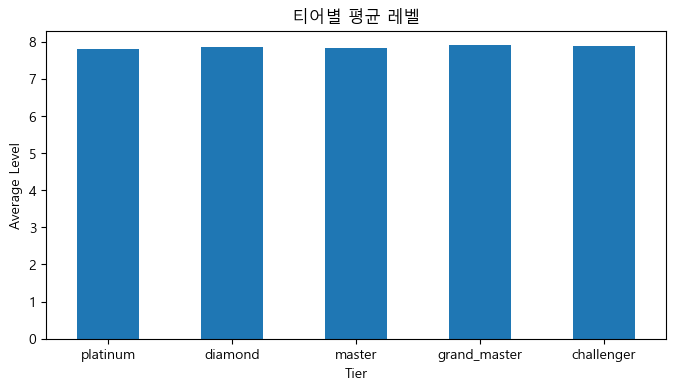

In [104]:
tier_summary['평균레벨'].plot(kind='bar', figsize=(8, 4))
plt.title('티어별 평균 레벨')
plt.xlabel('Tier')
plt.ylabel('Average Level')
plt.xticks(rotation=0)
plt.show()

<Figure size 800x500 with 0 Axes>

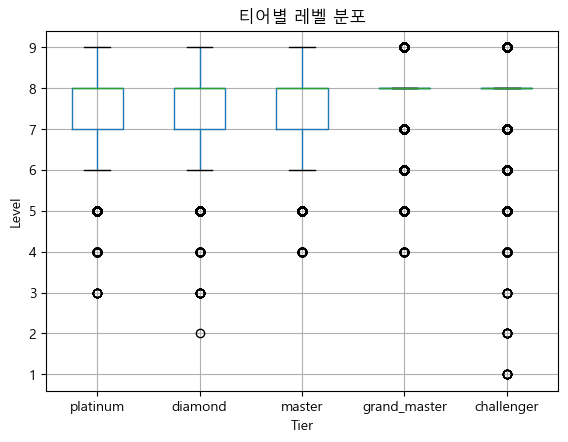

In [113]:
plt.figure(figsize=(8, 5))
df_g.boxplot(column='level', by='tier')
plt.title('티어별 레벨 분포')
plt.suptitle('')
plt.xlabel('Tier')
plt.ylabel('Level')
plt.show()

In [ ]:
# 각 티어별로 레벨별 비율(%)
level_dist = pd.crosstab(df_g['tier'], df_g['level'], normalize='index') * 100
level_dist.round(2)

level,1,2,3,4,5,6,7,8,9
tier,,,,,,,,,
platinum,0.00,0.00,0.01,0.08,1.01,4.78,23.93,53.96,16.22
diamond,0.00,0.00,0.02,0.06,0.75,3.98,21.94,55.10,18.15
master,0.00,0.00,0.00,0.05,0.75,3.91,21.91,56.95,16.42
grand_master,0.00,0.00,0.00,0.05,0.61,3.58,19.56,57.89,18.31
challenger,0.01,0.01,0.01,0.09,0.67,3.31,19.67,58.10,18.13


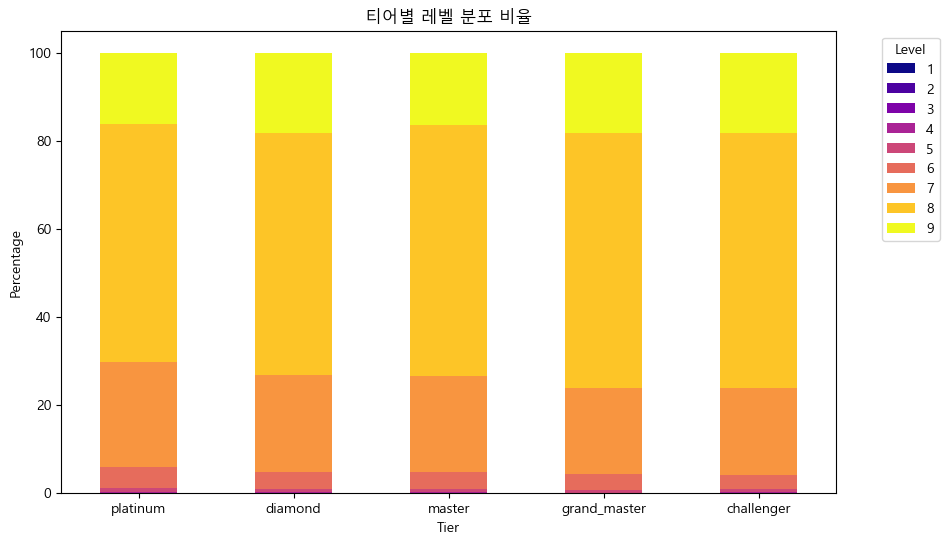

In [123]:
level_dist.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='plasma')
plt.title('티어별 레벨 분포 비율')
plt.xlabel('Tier')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

- 전체적으로 레벨 분포의 중심은 8레벨이었으며, 티어가 높아질수록 8레벨 도달 비율이 소폭 증가하는 모습을 보였다.

# 티어별 평균 마지막 라운드

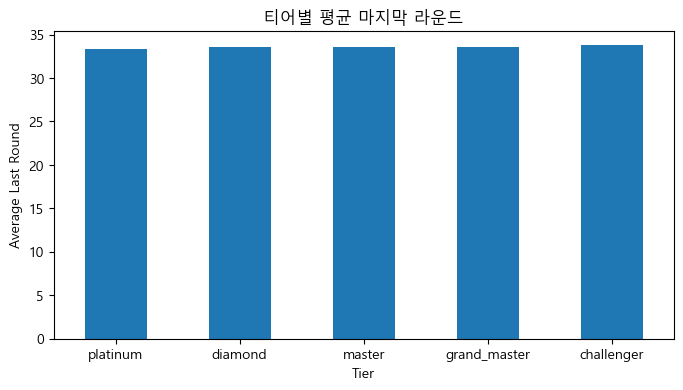

In [106]:
tier_summary['평균마지막라운드'].plot(kind='bar', figsize=(8, 4))
plt.title('티어별 평균 마지막 라운드')
plt.xlabel('Tier')
plt.ylabel('Average Last Round')
plt.xticks(rotation=0)
plt.show()

<Figure size 800x500 with 0 Axes>

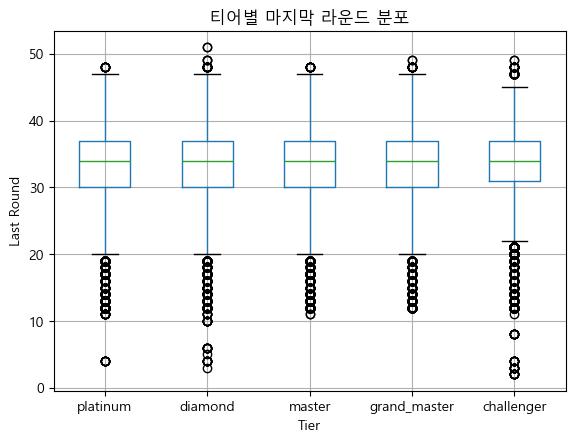

In [107]:
plt.figure(figsize=(8, 5))
df_g.boxplot(column='lastround', by='tier')
plt.title('티어별 마지막 라운드 분포')
plt.suptitle('')
plt.xlabel('Tier')
plt.ylabel('Last Round')
plt.show()

In [126]:
df_g.groupby('tier')['lastround'].agg(['mean', 'median', 'min', 'max']).round(2)

,mean,median,min,max
tier,,,,
platinum,33.29,34.0,4,48
diamond,33.58,34.0,3,51
master,33.54,34.0,11,48
grand_master,33.59,34.0,12,49
challenger,33.75,34.0,2,49


- 마지막 라운드의 대표값은 전 티어 공통으로 3-4였으며, 평균 기준으로는 상위 티어가 소폭 높았다.

# 티어별 평균 인게임시간

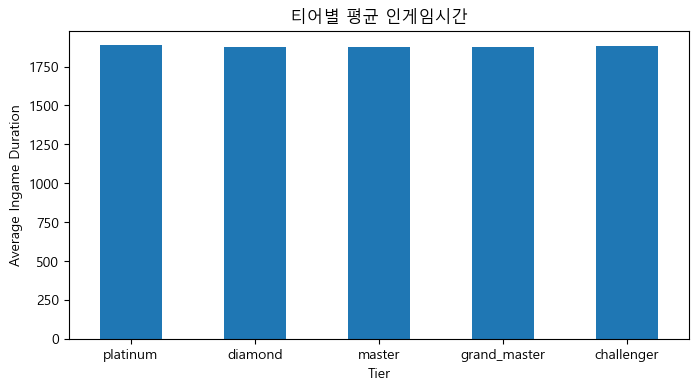

In [108]:
tier_summary['평균인게임시간'].plot(kind='bar', figsize=(8, 4))
plt.title('티어별 평균 인게임시간')
plt.xlabel('Tier')
plt.ylabel('Average Ingame Duration')
plt.xticks(rotation=0)
plt.show()

<Figure size 800x500 with 0 Axes>

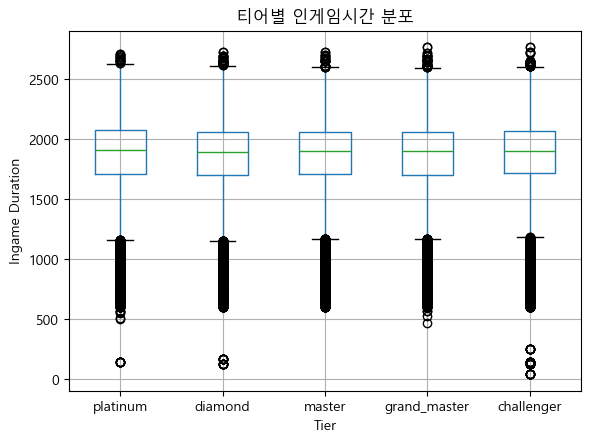

In [109]:
plt.figure(figsize=(8, 5))
df_g.boxplot(column='ingameduration', by='tier')
plt.title('티어별 인게임시간 분포')
plt.suptitle('')
plt.xlabel('Tier')
plt.ylabel('Ingame Duration')
plt.show()

In [127]:
df_g['ingameduration'].describe().round(2)

count    396488.00
mean       1879.56
std         267.74
min          38.89
25%        1706.85
50%        1900.86
75%        2067.38
max        2767.58
Name: ingameduration, dtype: float64

In [129]:
# 300초 미만 몇개?
(df_g['ingameduration'] < 300).sum()

np.int64(56)